## 4d

In [34]:
import scipy
import seaborn as sns
import matplotlib.pyplot as plt

from staticnet_invariance.deis_reconfigured import *
from staticnet_pilots.analyses import scatterplot_helper
from sklearn.decomposition import PCA
from scipy.spatial.distance import cosine,pdist,squareform,cdist

In [5]:
class NeuralRepresentation():
    def __init__(self,model_key=None,threshold = True,pca_file_path='resp_pca.pickle',device='cuda:0'):
        if model_key is None:
            model_key = {'group_id': 285,'net_hash': '8b6fe18fa651ebf452db0fbd77d05a01',
                         'data_hash': '7572eed73113c993e7d1b92f83e270b4','readout_key': 'group285-28120-4-9-9','seed': 1009,'ssid':1}
        if threshold:
            oracle, corr = (EnsembleEval.Unit & model_key).fetch('oracle_score', 'unit_avg_corr')
            ora_thre = np.percentile(oracle, 100 - np.sqrt(0.75)*100)
            corr_thre = np.percentile(corr, 100 - np.sqrt(0.75)*100)
            neuron_ids = (EnsembleEval.Unit & model_key & 'oracle_score > {} and unit_avg_corr > {}'.format(ora_thre, corr_thre)).fetch('neuron_id',order_by='neuron_id')
            model_key['neuron_id'] = neuron_ids
        else:
            model_key['neuron_id'] = slice(None, None, None)
        
        self.model = NeuralRepresentation.get_model(model_key,neuron_ids=model_key['neuron_id'],device=device)
        self.device = device
        
        if pca_file_path is None:
            pca = self.get_pca()
        else:
            if  os.path.exists(pca_file_path):
                with open(pca_file_path, 'rb') as handle:
                    pca = pickle.load(handle)
            else:
                pca = self.get_pca()
                with open(pca_file_path, 'wb') as handle:
                    pickle.dump(pca, handle, protocol=pickle.HIGHEST_PROTOCOL)
        self.pca = pca
        
    def get_model(key,neuron_ids=None,device='cuda:0',center=True):
        # Get model
        model_key = ({'group_id': key['group_id'], 'net_hash': key['net_hash']})
        all_keys = (static_models.Model & model_key & 'seed > 1000').fetch('KEY')
        all_models = [(static_models.Model & mk).load_network() for mk in all_keys]
        all_models = [model.to(device) for model in all_models]
        if center:
            # Set all the centers
            for model in all_models:
                model.readout[key['readout_key']].grid.data = torch.zeros_like(model.readout[key['readout_key']].grid,dtype=torch.float32,device=device)

        mean_eyepos = ([0, 0] if (Dataset.TrainStats & key).fetch1('norm_eyepos') else
                       (Dataset.TrainStats & key).fetch1('mean_eyepos'))
        mean_eyepos = torch.tensor(mean_eyepos, dtype=torch.float32, device=device).unsqueeze(0)
        if neuron_ids is not None:
            model = models.Ensemble(all_models, key['readout_key'], eye_pos=mean_eyepos,
                                    neuron_idx=neuron_ids, device=device, average_batch=False)
        else:
            model = models.Ensemble(all_models, key['readout_key'], eye_pos=mean_eyepos,
                                    device=device, average_batch=False)
        return model
    def pass_img(imgs,model,device,batch_size=32):
        import math
        n_batch = int(math.ceil(len(imgs)/batch_size))
        y = []
        with torch.no_grad():
            for x in np.array_split(imgs,n_batch):
                x = torch.tensor(x,dtype=torch.float32,device=device).unsqueeze(1)
                y.append(model(x).cpu().numpy().squeeze())
        return np.concatenate(y)
    
    def get_resp_helper(imgs,model,device='cuda:0'):
        resp_shape = list(imgs.squeeze().shape[:-2])+[-1]
        imgs = imgs.reshape(-1,imgs.shape[-2],imgs.shape[-1])
        resp = NeuralRepresentation.pass_img(imgs,model,device=device,batch_size=32).reshape(resp_shape)
        return resp
    
    def standardize_helper(x):
        return (x-x.mean())*0.25/x.std()
    
    def standardize(imgs,mask_x,mask_y,standardize_std=True):
        if len(imgs.squeeze().shape)<3:
            imgs = imgs[None,:,:]
        if standardize_std:
            imgs = np.stack([NeuralRepresentation.standardize_helper(ops.create_whole_mei(ops.center_and_crop_image(img,mask_x,mask_y)[0],None,0,0,(36,64),False)) for img in imgs])
        else:
            imgs = np.stack([ops.create_whole_mei(ops.center_and_crop_image(img,mask_x,mask_y)[0],None,0,0,(36,64),False) for img in imgs])
        return imgs
    
    def transform(self,imgs,mask_x,mask_y,standardize_std=True):
        imgs = NeuralRepresentation.standardize(imgs,mask_x,mask_y)
        resps = NeuralRepresentation.get_resp_helper(imgs,self.model,device=self.device)
        if len(resps.shape)<2:
            resps = resps[None,:]
        X = self.pca.transform(resps)
        return X
    
    def get_pca(self):
        # compile MEIs from all datasets
        all_meis, all_xs, all_ys = [], [], []
        groups = [233, 237, 239, 243, 271, 272, 275, 279, 284, 285, 329, 330, 336, 337]
        net_hash = ["8b6fe18fa651ebf452db0fbd77d05a01", "403a616c4761b733cb767a47a6d0e7da"]
        data_hash = ["7572eed73113c993e7d1b92f83e270b4"]
        group_keys = (base.EnsembleEval & 'ssid = 1' & [{'group_id': i} for i in groups] & [{'net_hash': i} for i in net_hash] & [{'data_hash': i} for i in data_hash]).fetch(dj.key, order_by='group_id')

        for key in group_keys:
            rest = {'mei_params': 10, 'mask_params': 3, 'seed': 1009}
            rel = base.UnitRanking.Unit & dict(ranking_params=4) & key
            oracle, corr = (EnsembleEval.Unit & key & rel).fetch('oracle_score', 'unit_avg_corr')
            ora_thre = np.percentile(oracle, 100 - np.sqrt(0.75)*100)
            corr_thre = np.percentile(corr, 100 - np.sqrt(0.75)*100)
            meis, xs, ys = (base.MEI * base.MEIMask * EnsembleEval.Unit & key & rel & 'oracle_score > {} and unit_avg_corr > {}'.format(ora_thre, corr_thre) & rest).fetch('mei', 'mask_x', 'mask_y', order_by='neuron_id')
            np.random.seed(1234)
            selected_idxs = np.random.choice(np.arange(len(meis)), 500, replace=False)
            all_meis.extend(meis[selected_idxs])
            all_xs.extend(xs[selected_idxs])
            all_ys.extend(ys[selected_idxs])
            
        meis = np.stack([NeuralRepresentation.standardize(mei,mask_x,mask_y,standardize_std=True) for mei,mask_x,mask_y in zip(all_meis,all_xs,all_ys)])
        resps = NeuralRepresentation.get_resp_helper(imgs = meis,model=self.model)
        from sklearn.decomposition import PCA
        pca = PCA()
        X = resps
        pca.fit(X)
        x = np.arange(1,len(pca.explained_variance_ratio_)+1)
        y = np.cumsum(pca.explained_variance_ratio_)
        x_thres = x[np.argmin(abs(y-0.95))]
        pca = PCA(n_components=x_thres)
        pca.fit(X)
        return pca
    
def permutation_test(X,n_repeats = 10000, seed=None):
    if seed is not None:
        np.random.seed(seed)
    diag_mean = np.diag(X).mean()
    bootstrap_means = []
    for _ in tqdm(range(n_repeats)):
        bootstrap_means.append(np.random.choice(X.ravel(),len(np.diag(X)),replace=False).mean())
    bootstrap_means = np.array(bootstrap_means)                 
    return (bootstrap_means>diag_mean).sum()/len(bootstrap_means)

def avg_pair_dist(x,y,n_dim=53):
    x = x.reshape(-1,n_dim)
    y = y.reshape(-1,n_dim)
    return (1.0-cdist(x,y,metric='cosine')).mean()

In [7]:
image_types = ['Original','Full texture','Partial texture']
keys = NeuronSetRequest & 'method_id = 3'

In [8]:
neural_representation = NeuralRepresentation()
dei_divs = {i:None for i in image_types}
pc_coefs = {i:[] for i in image_types}

full_1 = {'seed':1009, 'mei_params':10, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 14, 'threshold_params': 2, 'texture_params': 20,  'score_params': 2}
full_2 = {'seed':1009, 'mei_params':10, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 17, 'threshold_params': 2, 'texture_params': 20,  'score_params': 2}

for j in image_types:
    if j in ['Full texture','Partial texture']:
        if j == 'Partial texture':
            temp = [(MEIMask * Texture * TextureGoodRun & full_1 & keys & 'group_id <= 237'),
                    (MEIMask * Texture * TextureGoodRun & full_2 & keys & 'group_id > 237')]
        else:
            temp = [(MEIMask * Texture & {'texture_id':-1} & full_1 & keys & 'group_id <= 237'),
                    (MEIMask * Texture & {'texture_id':-1} & full_2 & keys & 'group_id > 237')]
            
        temp = [i.fetch('KEY','mask_x','mask_y','samples','sample_avg_div',order_by='group_id,neuron_id') for i in temp]
        deis = np.concatenate([np.array(i[-2]) for i in temp])
        dei_div = np.concatenate([np.array(i[-1]) for i in temp]) * -1.0
        mask_xs = np.concatenate([np.array(i[1]) for i in temp])
        mask_ys = np.concatenate([np.array(i[2]) for i in temp])
        dei_key = temp[0][0] + temp[1][0]
    
    else:
        temp = [(MEI * MEIMask * (DEI * DEIGoodRun) & full_1 & keys & 'group_id <= 237').proj(),
                (MEI * MEIMask * (DEI * DEIGoodRun) & full_2 & keys & 'group_id > 237').proj()]
        dei_key, meis, masks, mask_xs, mask_ys, deis, dei_div = (MEI * MEIMask * DEI * DEIGoodRun & temp).fetch('KEY','mei', 'mask','mask_x','mask_y','deis','avg_sim',order_by='group_id,neuron_id')

    dei_divs[j] = np.array(dei_div)*-1.0
    pc_coefs[j] = np.stack([neural_representation.transform(dei,mask_x,mask_y,standardize_std=True).squeeze() for dei,mask_x,mask_y in zip(deis,mask_xs,mask_ys)])

14-11-2025:07:54:40 INFO     configs.py           242:	 Ignoring input arguments: "net_hash", "core_hash", "ro_hash", "shift_hash", "mod_hash", "train_hash", "data_hash", "group_id", "seed", "train_type", "schedule", "max_epoch", "loss_type", "avg_loss"when creating datasets
14-11-2025:07:54:40 INFO     configs.py           222:	 Loading None dataset with tier=train
14-11-2025:07:54:41 WARNING  dataset_config.py     47:	 NeuroStaticFrame: The output frame format was not compatible with StatsConfig and led to an underestimated std of the images. This part table is deprecated and only kept for record keeping purposes.
14-11-2025:07:54:41 INFO     data_schemas.py     1318:	 Fetching data for {'group_id': 285, 'description': 'Inserted from PipelineManagement'}
14-11-2025:07:54:41 INFO     data_schemas.py     1328:	 Data will be (images,behavior,pupil_center,responses)
14-11-2025:07:54:41 INFO     data_schemas.py     1331:	 Loading dataset group285-28120-4-9-9 --> /dj-stor01/cache/static281

In [9]:
for i in image_types:
    print(i,pc_coefs[i].shape)

Original (1200, 20, 53)
Full texture (1200, 20, 53)
Partial texture (1200, 20, 53)


In [10]:
N_DIM=53

ps = {i:None for i in image_types}
dist_matrices = {i:None for i in image_types}
for image_type in tqdm(image_types):
    X = pc_coefs[image_type]
    dist_matrix = np.zeros([len(X),len(X)])
    for i in tqdm(range(len(X))):
        for j in range(len(X)):
            if i<=j:
                dist_matrix[i,j] = avg_pair_dist(X[i],X[j],n_dim=N_DIM)
            else:
                dist_matrix[i,j] = dist_matrix[j,i]
    dist_matrices[image_type] = dist_matrix

cross_dists = np.ones([len(image_types),len(image_types),len(pc_coefs[image_types[0]])])
p1s,p2s = np.ones([len(image_types),len(image_types)]), np.ones([len(image_types),len(image_types)])
np.random.seed(0)
for i,image_type1 in enumerate(image_types):    
    for j,image_type2 in enumerate(image_types):
        cross_dists[i,j] = np.array([avg_pair_dist(x,y,n_dim=N_DIM) for x,y in zip(pc_coefs[image_type1],pc_coefs[image_type2])])

100%|██████████| 3/3 [01:16<00:00, 25.49s/it]


In [11]:
cross_dists.shape

(3, 3, 1200)

### Get distance to random neurons from random samples in the off diagonal of the original DEI matrix

In [12]:
mat = dist_matrices[image_types[0]]
idxs = np.where(~np.eye(mat.shape[0],dtype=bool))
np.random.seed(1234)
cols = np.array([np.random.choice(i, 1).item() for i in idxs[1].reshape(len(mat), len(mat)-1)])
rows = np.arange(len(mat))
sampled_idxs = (rows, cols)
random_dists = mat[sampled_idxs]

### Get statistics (postive control)

In [13]:
from scipy.stats import wilcoxon
for i in range(1,len(image_types)):
    print(image_types[i])
    print(wilcoxon(cross_dists[0,0],cross_dists[0,i]))
print('Random DEIs')
print(wilcoxon(cross_dists[0,0],random_dists))

Full texture
WilcoxonResult(statistic=143.0, pvalue=1.1632446065670198e-197)
Partial texture
WilcoxonResult(statistic=41863.0, pvalue=5.723434814263819e-155)
Random DEIs
WilcoxonResult(statistic=5.0, pvalue=8.236953380877325e-198)


### Get statistics (negative control)

In [14]:
from scipy.stats import wilcoxon
ps = []
for i in range(len(image_types)):
    print(image_types[i])
    print(wilcoxon(random_dists,cross_dists[0,i]))
    ps.append(wilcoxon(random_dists,cross_dists[0,i])[-1])

Original
WilcoxonResult(statistic=5.0, pvalue=8.236953380877325e-198)
Full texture
WilcoxonResult(statistic=47786.0, pvalue=2.478605915500255e-149)
Partial texture
WilcoxonResult(statistic=1471.0, pvalue=3.201111791066149e-196)


In [15]:
wilcoxon(cross_dists[0,1], cross_dists[0,2])

WilcoxonResult(statistic=2387.0, pvalue=4.574990961063031e-195)

## Closed loop neurons

In [16]:
from staticnet_pilots.analyses import DEIClosedLoopSummaryResults
import pickle
with open('/dj-stor01/users/zhiwei/closed_loop_bad_matching_neurons_by_visual_inspection_on_summary_images.pickle', 'rb') as handle:
    manual_exclude_dic = pickle.load(handle)
    
def get_exclude_neurons(manual_exclude_dic, corr_thresh=0.42, dist_thresh=10, exclude_type='confusion', mei_key=None):
    if exclude_type == 'confusion':
        manual_exclude = manual_exclude_dic['{}-{}-{}'.format(*mei_key.values())]
        neuron_dics = (DEIClosedLoopSummaryResults.Neuron() & mei_key).fetch('neuron_id', 'matched_corr', 'matched_distance', as_dict=True, order_by='neuron_id')
        exclude_cols = [i for i, dic in enumerate(neuron_dics) if (dic['neuron_id'] in manual_exclude) or (dic['matched_corr'] < corr_thresh) or (dic['matched_distance'] > dist_thresh)]
        return exclude_cols
    else:
        manual_exclude = []
        for key, val in zip(manual_exclude_dic.keys(), manual_exclude_dic.values()):
            manual_exclude.extend([dict(animal_id=key.split('-')[0], session=key.split('-')[1], scan_idx=key.split('-')[2], neuron_id=n) for n in val])

        rel1 = DEIClosedLoopSummaryResults.Neuron & 'group_id in (241)'
        rel2 = DEIClosedLoopSummaryResults.Neuron & manual_exclude
        rel3 = DEIClosedLoopSummaryResults.Neuron & 'group_id not in (241) and matched_corr < {} or matched_distance > {}'.format(corr_thresh, dist_thresh)
        rel4 = DEIClosedLoopSummaryResults.Neuron & 'animal_id = 27470 and session = 7 and scan_idx = 12'
        # rel4 = DEIClosedLoopSummaryResults.Neuron & 'animal_id = 27470 and session = 6 and scan_idx = 8' # accidentally showed exact same stimuli for 27470-6-8 and 27470-7-12

        return rel1.proj() + rel2.proj() + rel3.proj() + rel4.proj()
    
# closed loop neurons
rest = ['group_id in (233, 237, 239, 243) and stim_type in ("dei_texture_multi") and params_id !=4',
        'group_id in (272, 275, 279, 284) and stim_type in ("dei_texture_package") and params_id !=4']
exclude = get_exclude_neurons(manual_exclude_dic, exclude_type='scatter')
neuron_rel = (DEIClosedLoopSummaryResults.Neuron - exclude) & rest
rest1 = 'group_id <= 237 and seed = 1009 and net_hash in ("8b6fe18fa651ebf452db0fbd77d05a01", "403a616c4761b733cb767a47a6d0e7da") and data_hash = "7572eed73113c993e7d1b92f83e270b4" and mei_params = 10 and mask_params = 3 and diverse_params = 14 and texture_params = 13 and score_params = 2 and threshold_params = 2'
rest2 = 'group_id > 237 and seed = 1009 and net_hash in ("8b6fe18fa651ebf452db0fbd77d05a01", "403a616c4761b733cb767a47a6d0e7da") and data_hash = "7572eed73113c993e7d1b92f83e270b4" and mei_params = 10 and mask_params = 3 and diverse_params = 17 and texture_params = 20 and score_params = 2 and threshold_params = 2'

meis, masks, xs, ys, original_deis, partial_deis = (MEI * MEIMask * DEI * Texture & (TextureGoodRun & [rest1, rest2] & neuron_rel)).fetch('mei', 'mask', 'mask_x', 'mask_y', 'deis', 'samples', order_by='group_id, neuron_id')
full_deis = (Texture & (TextureGoodRun & [rest1, rest2] & neuron_rel).proj(dummy='texture_id') & 'texture_id = -1').fetch('samples', order_by='group_id, neuron_id')

pc_coefs = {i:[] for i in image_types}
for j, deis in tqdm(zip(image_types, [original_deis, full_deis, partial_deis])):
    pc_coefs[j] = np.stack([neural_representation.transform(dei,mask_x,mask_y,standardize_std=True).squeeze() for dei,mask_x,mask_y in zip(deis,xs,ys)])

3it [01:15, 25.17s/it]


In [17]:
for i in image_types:
    print(i, pc_coefs[i].shape)

Original (401, 20, 53)
Full texture (401, 20, 53)
Partial texture (401, 20, 53)


In [18]:
N_DIM=53

ps = {i:None for i in image_types}
dist_matrices = {i:None for i in image_types}
for image_type in tqdm(image_types):
    X = pc_coefs[image_type]
    dist_matrix = np.zeros([len(X),len(X)])
    for i in tqdm(range(len(X))):
        for j in range(len(X)):
            if i<=j:
                dist_matrix[i,j] = avg_pair_dist(X[i],X[j],n_dim=N_DIM)
            else:
                dist_matrix[i,j] = dist_matrix[j,i]
    dist_matrices[image_type] = dist_matrix

cl_cross_dists = np.ones([len(image_types),len(image_types),len(pc_coefs[image_types[0]])])
p1s,p2s = np.ones([len(image_types),len(image_types)]), np.ones([len(image_types),len(image_types)])
np.random.seed(0)
for i,image_type1 in enumerate(image_types):    
    for j,image_type2 in enumerate(image_types):
        cl_cross_dists[i,j] = np.array([avg_pair_dist(x,y,n_dim=N_DIM) for x,y in zip(pc_coefs[image_type1],pc_coefs[image_type2])])

100%|██████████| 3/3 [00:08<00:00,  2.88s/it]


### Get distance to random neurons from random samples in the off diagonal of the original DEI matrix

In [19]:
mat = dist_matrices[image_types[0]]
idxs = np.where(~np.eye(mat.shape[0],dtype=bool))
np.random.seed(1234)
cols = np.array([np.random.choice(i, 1).item() for i in idxs[1].reshape(len(mat), len(mat)-1)])
rows = np.arange(len(mat))
sampled_idxs = (rows, cols)
random_dists = mat[sampled_idxs]

### Get statistics (postive control)

In [20]:
from scipy.stats import wilcoxon
for i in range(1,len(image_types)):
    print(image_types[i])
    print(wilcoxon(cl_cross_dists[0,0],cl_cross_dists[0,i]))
print('Random DEIs')
print(wilcoxon(cl_cross_dists[0,0],random_dists))

Full texture
WilcoxonResult(statistic=11.0, pvalue=2.0350887561634235e-67)
Partial texture
WilcoxonResult(statistic=10319.0, pvalue=3.9686826534052323e-38)
Random DEIs
WilcoxonResult(statistic=0.0, pvalue=1.8740233927451233e-67)


### Get statistics (negative control)

In [21]:
from scipy.stats import wilcoxon
ps = []
for i in range(len(image_types)):
    print(image_types[i])
    print(wilcoxon(random_dists,cl_cross_dists[0,i]))
    ps.append(wilcoxon(random_dists,cl_cross_dists[0,i])[-1])

Original
WilcoxonResult(statistic=0.0, pvalue=1.8740233927451233e-67)
Full texture
WilcoxonResult(statistic=5255.0, pvalue=1.8788186253610285e-51)
Partial texture
WilcoxonResult(statistic=34.0, pvalue=2.4178200359694944e-67)


In [23]:
wilcoxon(cl_cross_dists[0,1], cl_cross_dists[0,2])

WilcoxonResult(statistic=65.0, pvalue=3.049502068730935e-67)

### Plot similarity

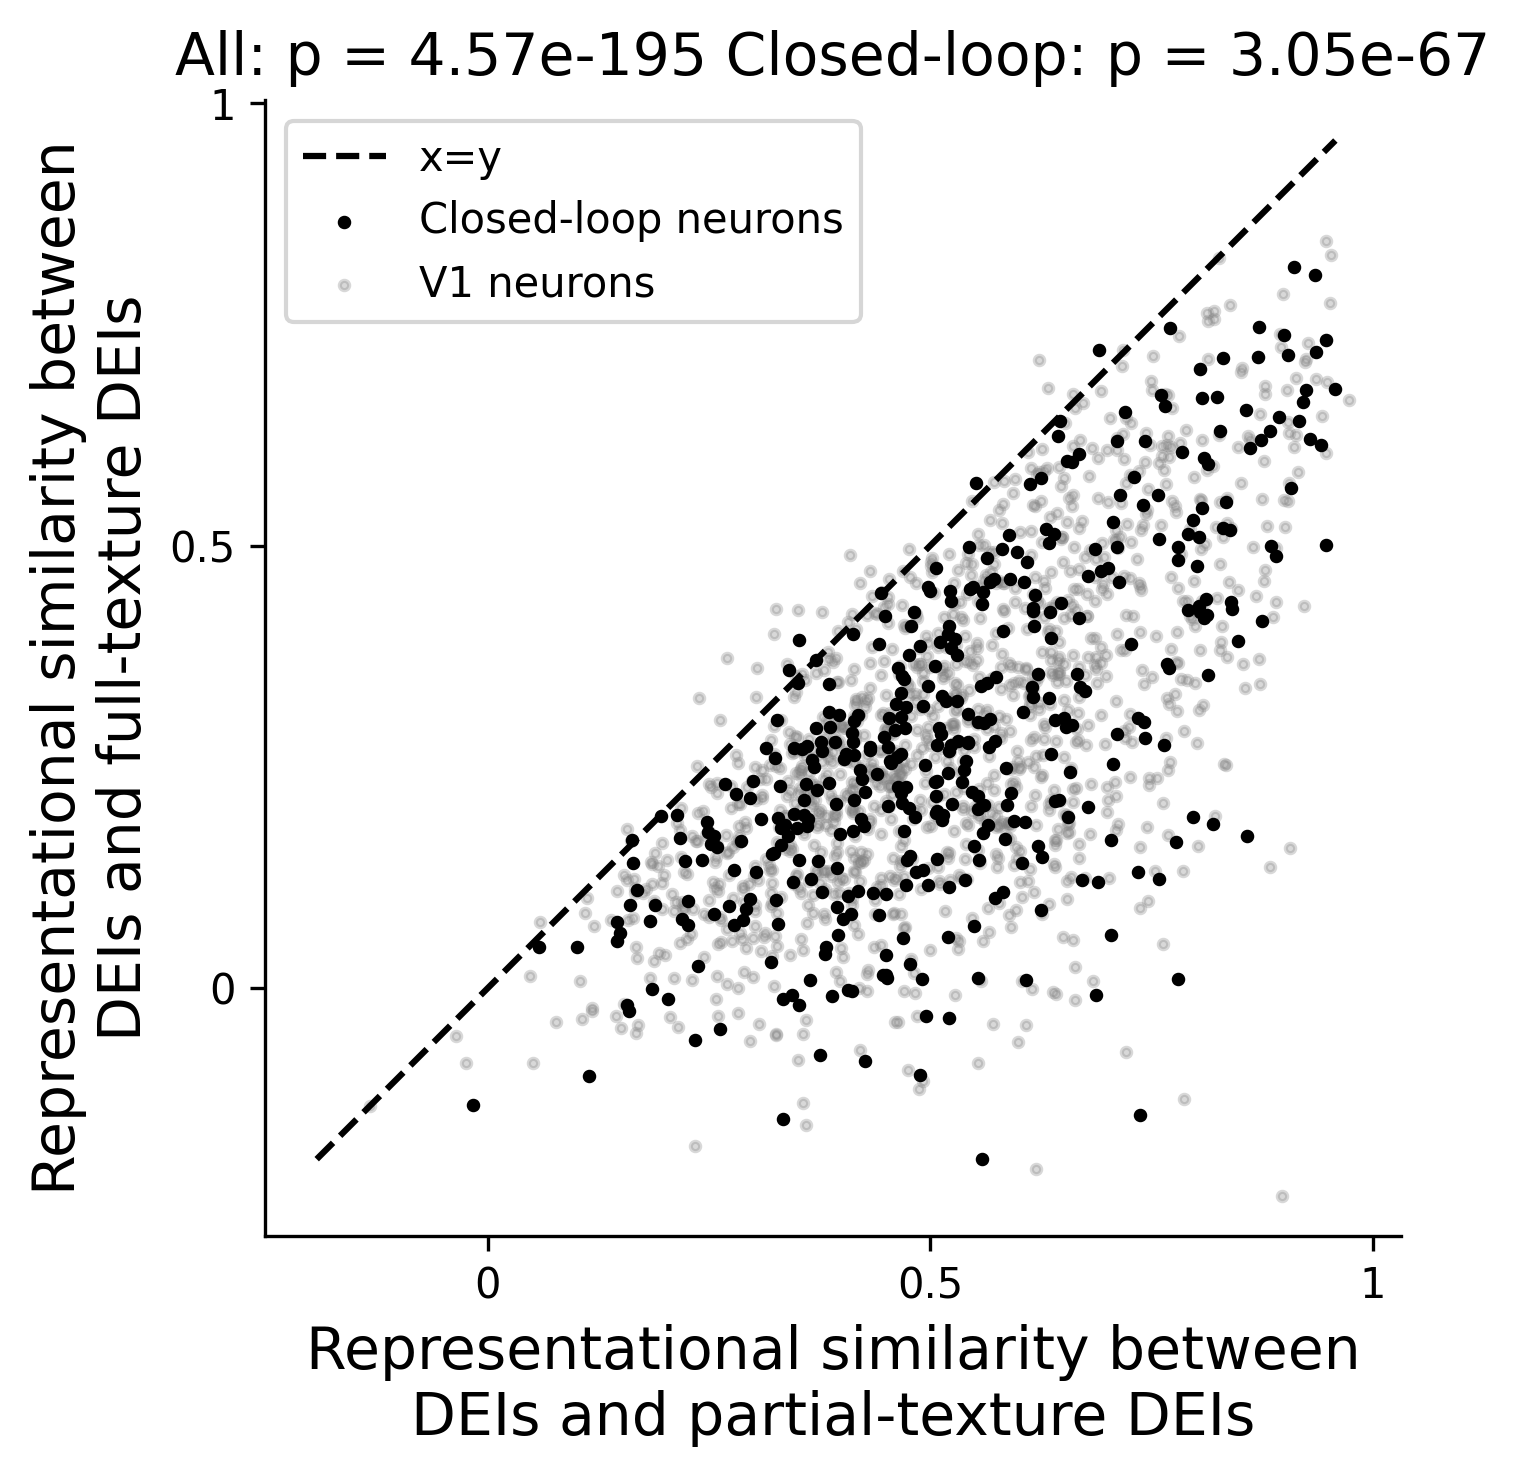

In [36]:
scatterplot_helper(cl_cross_dists[0,2], cl_cross_dists[0,1], 'Representational similarity between\nDEIs and partial-texture DEIs', 'Representational similarity between\nDEIs and full-texture DEIs', get_bound_from_data=True, fit=False, figsize=(5, 5), label='Closed-loop neurons')
plt.scatter(cross_dists[0,2], cross_dists[0,1], color='gray', s=5, alpha=0.3, label='V1 neurons', zorder=0)
plt.legend(fontsize=10)
plt.xticks([0,0.5,1], [0,0.5,1])
plt.yticks([0,0.5,1], [0,0.5,1])
plt.axis('equal')
p_wc_loop = scipy.stats.wilcoxon(cl_cross_dists[0,2], cl_cross_dists[0,1])[1]
p_wc_all = scipy.stats.wilcoxon(cross_dists[0,2], cross_dists[0,1])[1]
plt.title('All: p = {} Closed-loop: p = {}'.format(np.format_float_scientific(p_wc_all, precision=2), np.format_float_scientific(p_wc_loop, precision=2)), fontsize=14)

plt.savefig('/src/notebooks/Official_figures/[Fig4_d]Texture_DEI_Similarity_to_original_DEIs_scatter_version.pdf', transparent=True)

## 4e

In [37]:
import math
import pickle

import datajoint as dj
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as plticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import ndimage
import scipy
import seaborn as sns
import torch
from tqdm import tqdm
from scipy.stats import wilcoxon, ttest_ind, ttest_1samp
from statsmodels.stats.multitest import multipletests

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

from featurevis.ops import center_and_crop_image, standardize_image
from staticnet_analyses import base, gabors
from staticnet_pilots.analyses import *
from staticnet_invariance import (
    dei_stimulus_reconfigured as dei_stimulus,
    deis_reconfigured as deis_schema,
    toy,
    toy_deis,
)
from staticnet_invariance.segmentation import find_cross

stimulus = dj.create_virtual_module('stimulus', 'pipeline_stimulus')
imagenet = dj.create_virtual_module('pipeline_imagenet', 'pipeline_imagenet')
experiment = dj.create_virtual_module('pipeline_experiment', 'pipeline_experiment')
meso = dj.create_virtual_module('pipeline_meso', 'pipeline_meso')
fuse = dj.create_virtual_module('fuse', 'pipeline_fuse')
collection = dj.create_virtual_module('collection', 'pipeline_collection')

# get manually curated neuron information 
with open('/dj-stor01/users/zhiwei/closed_loop_bad_matching_neurons_by_visual_inspection_on_summary_images.pickle', 'rb') as handle:
    manual_exclude_dic = pickle.load(handle)
    
def get_exclude_neurons(manual_exclude_dic, corr_thresh=0.42, dist_thresh=10, exclude_type='confusion', mei_key=None):
    if exclude_type == 'confusion':
        manual_exclude = manual_exclude_dic['{}-{}-{}'.format(*mei_key.values())]
        neuron_dics = (DEIClosedLoopSummaryResults.Neuron() & mei_key).fetch('neuron_id', 'matched_corr', 'matched_distance', as_dict=True, order_by='neuron_id')
        exclude_cols = [i for i, dic in enumerate(neuron_dics) if (dic['neuron_id'] in manual_exclude) or (dic['matched_corr'] < corr_thresh) or (dic['matched_distance'] > dist_thresh)]
        return exclude_cols
    else:
        manual_exclude = []
        for key, val in zip(manual_exclude_dic.keys(), manual_exclude_dic.values()):
            manual_exclude.extend([dict(animal_id=key.split('-')[0], session=key.split('-')[1], scan_idx=key.split('-')[2], neuron_id=n) for n in val])

        rel1 = DEIClosedLoopSummaryResults.Neuron & 'group_id in (241)'
        rel2 = DEIClosedLoopSummaryResults.Neuron & manual_exclude
        rel3 = DEIClosedLoopSummaryResults.Neuron & 'group_id not in (241) and matched_corr < {} or matched_distance > {}'.format(corr_thresh, dist_thresh)
        rel4 = DEIClosedLoopSummaryResults.Neuron & 'animal_id = 27470 and session = 7 and scan_idx = 12'
        # rel4 = DEIClosedLoopSummaryResults.Neuron & 'animal_id = 27470 and session = 6 and scan_idx = 8' # accidentally showed exact same stimuli for 27470-6-8 and 27470-7-12

        return rel1.proj() + rel2.proj() + rel3.proj() + rel4.proj()

def cal_dof(x,y):
    a = x.std()**2/len(x)
    b = y.std()**2/len(y)
    return (a+b)**2 / (a**2/(len(x)-1) + b**2/(len(y)-1))

# x,y has format n_pts*n_repeats(or observations)
def get_stat(x, y, alternative='two-sided'):
    print(wilcoxon(x.mean(axis=1),y.mean(axis=1), alternative=alternative))
    print('DOF: {:.2f}'.format(np.nanmean([cal_dof(i,j) for i,j in zip(x,y)])))

    stats = np.array([ttest_ind(i,j,equal_var=False, alternative=alternative) for i,j in zip(x,y)])
    temp = stats[:,0][stats[:,1]<0.05]
    print('Prior correction: Different {} {:.2f}% Less {} {:.2f}%, Greater {} {:.2f}%'.format(len(temp), len(temp)/len(x)*100, (temp<0).sum(), (temp<0).sum()/len(x)*100, (temp>0).sum(), (temp>0).sum()/len(x)*100))

    cr_temp = stats[:,0][multipletests(stats[:,1],0.05,method="fdr_bh")[0]]
    print('Post correction: Different {} {:.2f}% Less {} {:.2f}%, Greater {} {:.2f}%'.format(len(cr_temp), len(cr_temp)/len(x)*100, (cr_temp<0).sum(), (cr_temp<0).sum()/len(x)*100, (cr_temp>0).sum(), (cr_temp>0).sum()/len(x)*100))

/usr/local/lib/python3.8/dist-packages/skimage/io/manage_plugins.py:23: UserWarning: Your installed pillow version is < 8.1.2. Several security issues (CVE-2021-27921, CVE-2021-25290, CVE-2021-25291, CVE-2021-25293, and more) have been fixed in pillow 8.1.2 or higher. We recommend to upgrade this library.
  from .collection import imread_collection_wrapper


You should consider upgrading via the '/usr/local/bin/python -m pip install --upgrade pip' command.


## 4f

In [45]:
n_repeats = 20
n_subtypes = 3
rest = ['group_id in (233, 237, 239, 243) and stim_type in ("dei_texture_multi") and params_id !=4',
        'group_id in (272, 275, 279, 284) and stim_type in ("dei_texture_package") and params_id !=4']
labels = ['DEIs', 'full texture DEIs', 'partial texture DEIs']

exclude = get_exclude_neurons(manual_exclude_dic, exclude_type='scatter')
neuron_rel = (DEIClosedLoopSummaryResults.Neuron - exclude)
n_neurons = len(neuron_rel & rest)
real, subtypes = (DEIClosedLoopSummaryResults.Subtype & neuron_rel & rest & 'subtype in ("dei", "local_dei", "full_dei")').fetch('real_response', 'subtype', order_by='group_id, neuron_id, subtype')
real = np.stack(real).reshape(n_neurons, n_subtypes, n_repeats)
subtypes = np.stack(subtypes).reshape(n_neurons, n_subtypes)

all_diags = real.mean(-1).T
all_std_diags = real.std(-1).T
dei_mean = all_diags[0]
dei_std = all_std_diags[0]

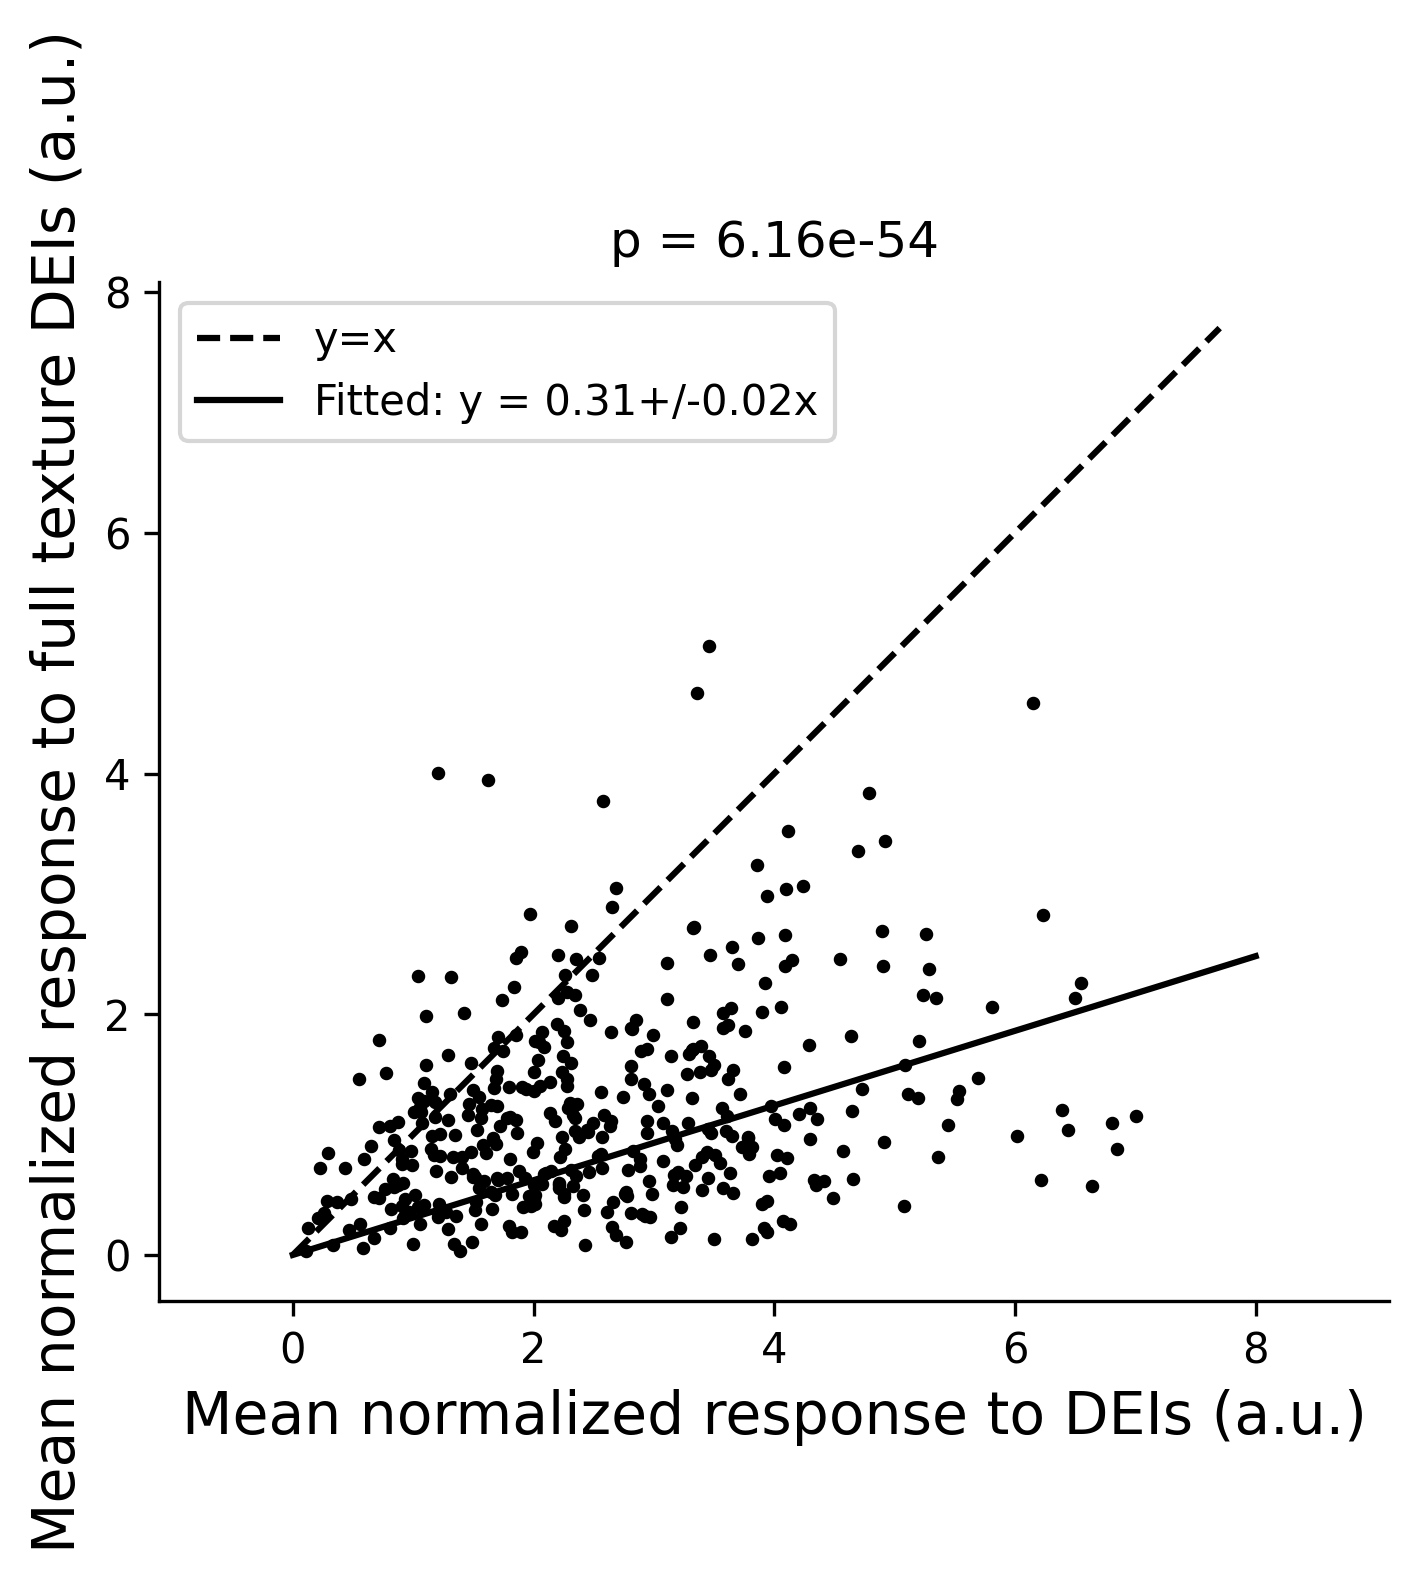

In [46]:
idx = 1
texture_mean = all_diags[idx]
texture_std = all_std_diags[idx]
l = labels[idx]
p_thresh = 0.05

plt.figure(figsize=(5, 5), dpi=300)

ps = np.array([scipy.stats.ttest_ind_from_stats(m1,s1,n_repeats,m2,s2,n_repeats, equal_var=False)[1] for m1,s1,m2,s2 in zip(texture_mean, texture_std, dei_mean, dei_std)])
p_wc = scipy.stats.wilcoxon(texture_mean, dei_mean)[1]

plt.scatter(dei_mean[ps>p_thresh], texture_mean[ps>p_thresh], color='k', s=5)
plt.scatter(dei_mean[ps<=p_thresh], texture_mean[ps<=p_thresh], color='k', s=5)
max_val = all_diags.max()

plt.title('p = {}'.format(np.format_float_scientific(p_wc, precision=2)))

plt.ylabel('Mean normalized response to {} (a.u.)'.format(l), fontsize=14)
plt.xlabel('Mean normalized response to DEIs (a.u.)', fontsize=14)

plt.plot([0, max_val], [0, max_val], color='k', linestyle='dashed', label='y=x')

# Linear fit 
from sklearn import linear_model
x_range = np.linspace(0, np.ceil(max_val), 6)
x = dei_mean
y = texture_mean
x_fit = x[:, np.newaxis]
coefs = []
for i in range(1000):
    ransac = linear_model.RANSACRegressor(base_estimator=linear_model.LinearRegression(fit_intercept=False), max_trials=1000)
    ransac.fit(x_fit, y)
    coefs.append(ransac.estimator_.coef_.item())
coef = np.mean(coefs)
std_coef = np.std(coefs)
plt.plot(x_range, coef*x_range, color='k', label='Fitted: y = {:.2f}+/-{:.2f}x'.format(coef, std_coef))
plt.xticks(x_range)
plt.yticks(x_range)

plt.legend()
sns.despine()
plt.tight_layout()
plt.xticks([0, 2, 4, 6, 8], [0, 2, 4, 6, 8])
plt.yticks([0, 2, 4, 6, 8], [0, 2, 4, 6, 8])
plt.axis('equal')

plt.savefig('/src/notebooks/Official_figures/[Fig4_e]Comparison_of_DEI_vs_{}_responses.pdf'.format(l), transparent=True)

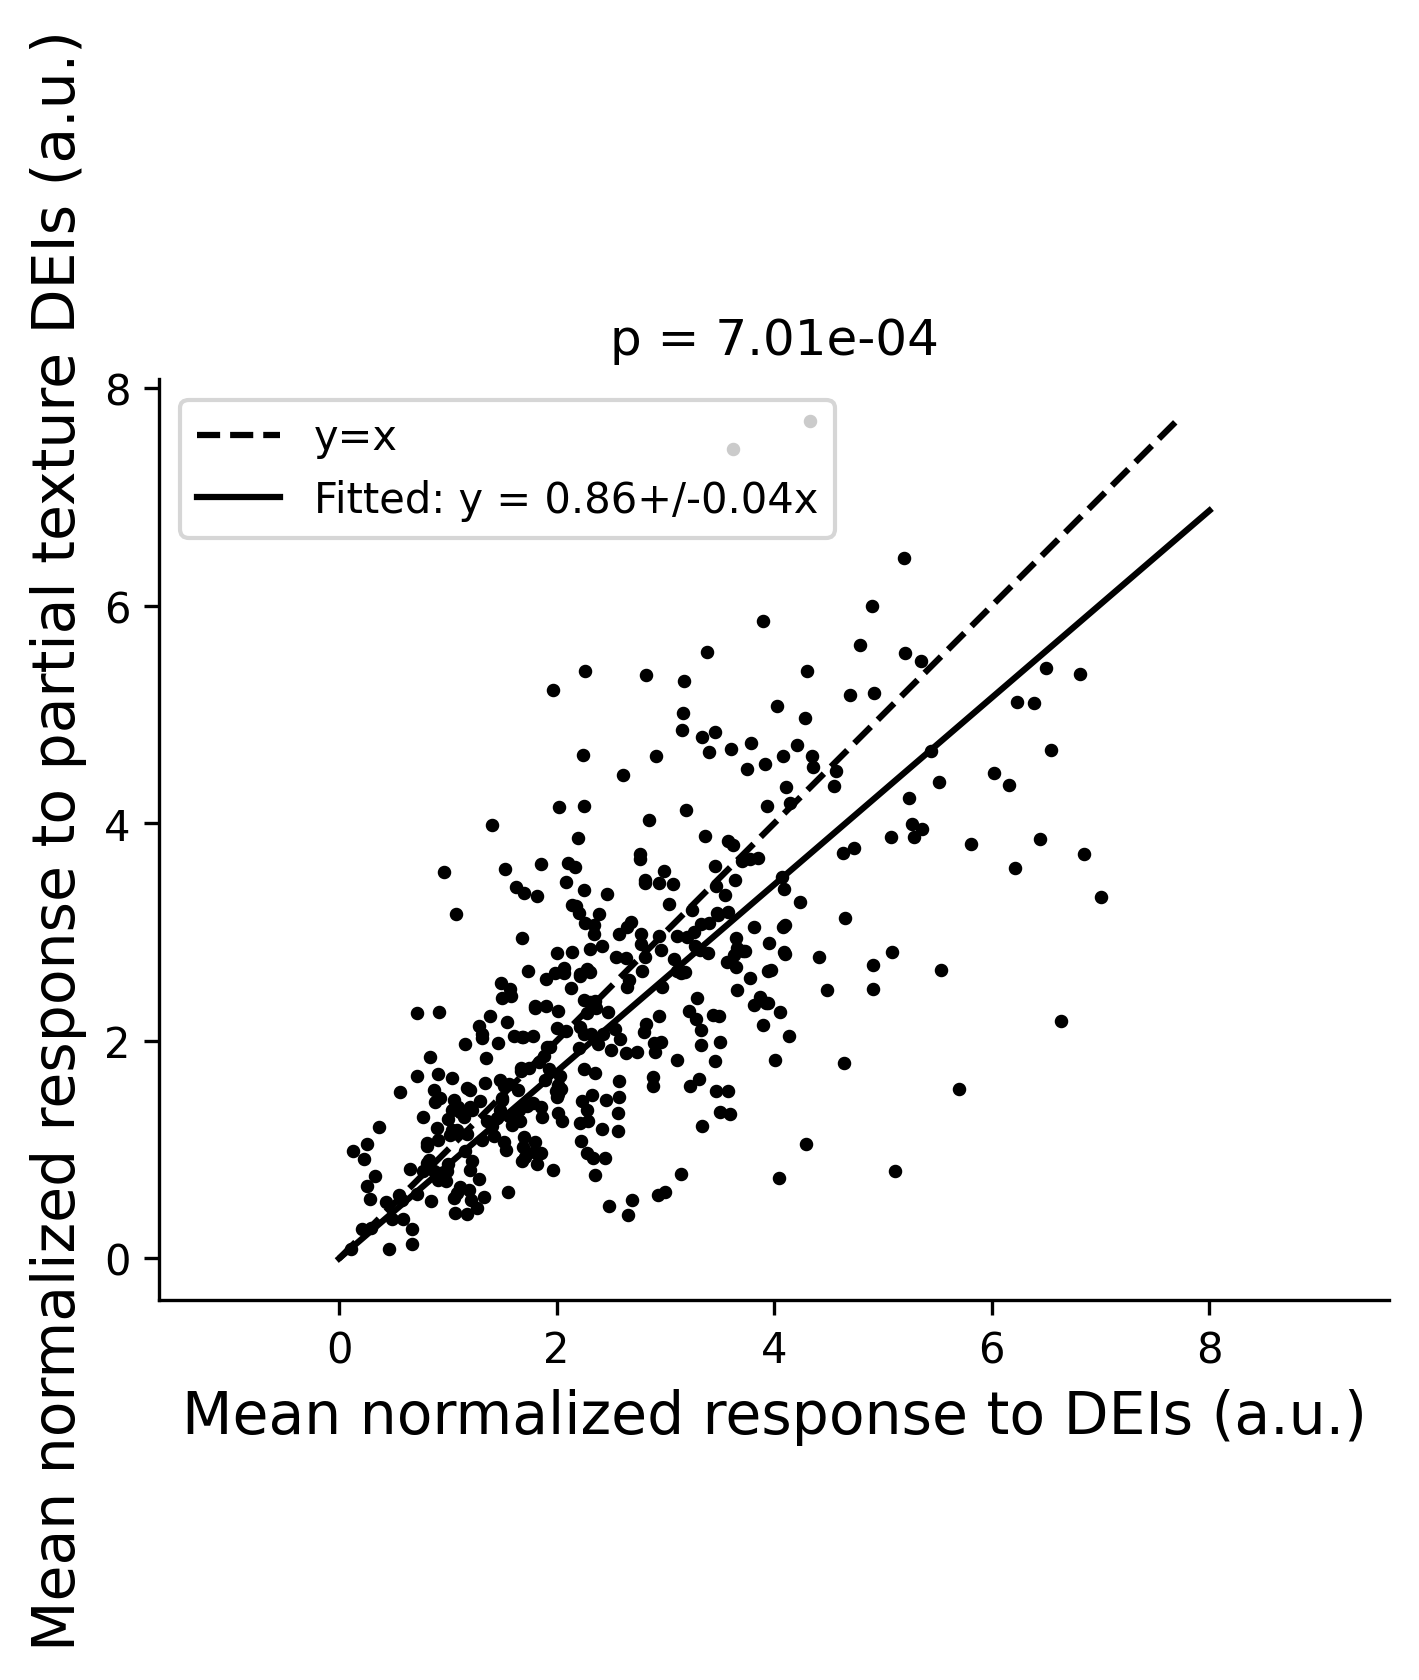

In [48]:
idx = 2
texture_mean = all_diags[idx]
texture_std = all_std_diags[idx]
l = labels[idx]
p_thresh = 0.05

plt.figure(figsize=(5, 5), dpi=300)

ps = np.array([scipy.stats.ttest_ind_from_stats(m1,s1,n_repeats,m2,s2,n_repeats, equal_var=False)[1] for m1,s1,m2,s2 in zip(texture_mean, texture_std, dei_mean, dei_std)])
p_wc = scipy.stats.wilcoxon(texture_mean, dei_mean)[1]

plt.scatter(dei_mean[ps>p_thresh], texture_mean[ps>p_thresh], color='k', s=5)
plt.scatter(dei_mean[ps<=p_thresh], texture_mean[ps<=p_thresh], color='k', s=5)
max_val = all_diags.max()

plt.title('p = {}'.format(np.format_float_scientific(p_wc, precision=2)))

plt.ylabel('Mean normalized response to {} (a.u.)'.format(l), fontsize=14)
plt.xlabel('Mean normalized response to DEIs (a.u.)', fontsize=14)

plt.plot([0, max_val], [0, max_val], color='k', linestyle='dashed', label='y=x')

# Linear fit 
from sklearn import linear_model
x_range = np.linspace(0, np.ceil(max_val), 6)
x = dei_mean
y = texture_mean
x_fit = x[:, np.newaxis]
coefs = []
for i in range(1000):
    ransac = linear_model.RANSACRegressor(base_estimator=linear_model.LinearRegression(fit_intercept=False), max_trials=1000)
    ransac.fit(x_fit, y)
    coefs.append(ransac.estimator_.coef_.item())
coef = np.mean(coefs)
std_coef = np.std(coefs)
plt.plot(x_range, coef*x_range, color='k', label='Fitted: y = {:.2f}+/-{:.2f}x'.format(coef, std_coef))
plt.xticks(x_range)
plt.yticks(x_range)

plt.legend()
sns.despine()
plt.tight_layout()
plt.xticks([0, 2, 4, 6, 8], [0, 2, 4, 6, 8])
plt.yticks([0, 2, 4, 6, 8], [0, 2, 4, 6, 8])
plt.axis('equal')

plt.savefig('/src/notebooks/Official_figures/[Fig4_f]Comparison_of_DEI_vs_{}_responses.pdf'.format(l), transparent=True)

## 4g

In [60]:
# real neurons
rest1 = 'group_id <= 237 and seed = 1009 and net_hash in ("8b6fe18fa651ebf452db0fbd77d05a01", "403a616c4761b733cb767a47a6d0e7da") and data_hash = "7572eed73113c993e7d1b92f83e270b4" and mei_params = 10 and mask_params = 3 and diverse_params = 14 and texture_params = 20 and threshold_params = 2 and score_params = 2'
rest2 = 'group_id > 237 and seed = 1009 and net_hash in ("8b6fe18fa651ebf452db0fbd77d05a01", "403a616c4761b733cb767a47a6d0e7da") and data_hash = "7572eed73113c993e7d1b92f83e270b4" and mei_params = 10 and mask_params = 3 and diverse_params = 17 and texture_params = 20 and threshold_params = 2 and score_params = 2'
div, vsize = (deis_schema.DEI * deis_schema.Texture & (deis_schema.NeuronSetRequest & 'method_id = 3') & (deis_schema.TextureGoodRun & [rest1, rest2])).fetch('avg_sim', 'p', order_by='group_id, neuron_id')

rest1 = 'group_id <= 237 and seed = 1009 and net_hash in ("8b6fe18fa651ebf452db0fbd77d05a01", "403a616c4761b733cb767a47a6d0e7da") and data_hash = "7572eed73113c993e7d1b92f83e270b4" and mei_params = 10 and mask_params = 3 and diverse_params = 14 and texture_params = 20 and threshold_params = 2'
rest2 = 'group_id > 237 and seed = 1009 and net_hash in ("8b6fe18fa651ebf452db0fbd77d05a01", "403a616c4761b733cb767a47a6d0e7da") and data_hash = "7572eed73113c993e7d1b92f83e270b4" and mei_params = 10 and mask_params = 3 and diverse_params = 17 and texture_params = 20 and threshold_params = 2'

ps, acts = (deis_schema.Texture & (deis_schema.NeuronSetRequest & 'method_id = 3') & [rest1, rest2]).fetch('p', 'sample_avg_activation_ratio', order_by='group_id, neuron_id, texture_id')
ps = ps.reshape(-1, 10)
acts = acts.reshape(-1, 10)
real_ps, real_acts = [], []
for p, act in zip(ps, acts):
    p_, act_ = process_p_and_act(p, act)
    real_ps.append(p_)
    real_acts.append(act_)
    
real_ps_fscore, real_ps_target, real_auc, real_auc_raw, real_fitted_act = [], [], [], [], []
for p, act in zip(real_ps, real_acts):
    fitted_p, fitted_act = deis_schema.spline_fit(p, act, processed=True, mode='spline')
    real_fitted_act.append(fitted_act)
    real_auc.append(deis_schema.auc_cal(fitted_p, fitted_act))
    real_auc_raw.append(deis_schema.auc_cal(p, act))

# closed loop neurons
rest = ['group_id in (233, 237, 239, 243) and stim_type in ("dei_texture_multi") and params_id !=4',
        'group_id in (272, 275, 279, 284) and stim_type in ("dei_texture_package") and params_id !=4']
exclude = get_exclude_neurons(manual_exclude_dic, exclude_type='scatter')
neuron_rel = (DEIClosedLoopSummaryResults.Neuron - exclude) & rest
rest1 = 'group_id <= 237 and seed = 1009 and net_hash in ("8b6fe18fa651ebf452db0fbd77d05a01", "403a616c4761b733cb767a47a6d0e7da") and data_hash = "7572eed73113c993e7d1b92f83e270b4" and mei_params = 10 and mask_params = 3 and diverse_params = 14 and texture_params = 13 and threshold_params = 2'
rest2 = 'group_id > 237 and seed = 1009 and net_hash in ("8b6fe18fa651ebf452db0fbd77d05a01", "403a616c4761b733cb767a47a6d0e7da") and data_hash = "7572eed73113c993e7d1b92f83e270b4" and mei_params = 10 and mask_params = 3 and diverse_params = 17 and texture_params = 20 and threshold_params = 2'
ps, acts = (deis_schema.Texture & [rest1, rest2] & neuron_rel).fetch('p', 'sample_avg_activation_ratio', order_by='group_id, neuron_id, texture_id')
ps = ps.reshape(-1, 10)
acts = acts.reshape(-1, 10)
loop_ps, loop_acts = [], []
for p, act in zip(ps, acts):
    p_, act_ = process_p_and_act(p, act)
    loop_ps.append(p_)
    loop_acts.append(act_)
    
loop_ps_fscore, loop_ps_target, loop_auc, loop_fitted_act = [], [], [], []
for p, act in zip(loop_ps, loop_acts):
    fitted_p, fitted_act = deis_schema.spline_fit(p, act, processed=True, mode='spline')
    loop_fitted_act.append(fitted_act)
    loop_auc.append(deis_schema.auc_cal(fitted_p, fitted_act))


# toy neurons 
toy_rest = {'group_id': 6, 'mei_params': 1, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 22, 'threshold_params': 2, 'texture_params': 20, 'score_params': 2}
ps, acts = \
(toy_deis.MEI * toy_deis.MEIMask * toy_deis.DEINew * toy_deis.DEINewGoodRun * \
toy_deis.DEINewGoodRunLookup * toy_deis.Texture *\
(toy.GroupAssignment.Member * toy.ToyNeuron).proj('parameters') & toy_rest
).fetch('p', 'sample_avg_activation_ratio', order_by='group_id, member_id, texture_id')
ps = ps.reshape(-1, 10)
acts = acts.reshape(-1, 10)
toy_ps, toy_acts = [], []
for p, act in zip(ps, acts):
    p_, act_ = process_p_and_act(p, act)
    toy_ps.append(p_)
    toy_acts.append(act_)

toy_ps_fscore, toy_ps_target, toy_auc, toy_fitted_act = [], [], [], []
for p, act in zip(toy_ps, toy_acts):
    fitted_p, fitted_act = deis_schema.spline_fit(p, act, processed=True, mode='spline')
    toy_fitted_act.append(fitted_act)
    toy_auc.append(deis_schema.auc_cal(fitted_p, fitted_act))
    

/usr/local/lib/python3.8/dist-packages/datajoint/connection.py:219: UserWarning: MySQL server has gone away. Reconnecting to the server.
  warnings.warn("MySQL server has gone away. Reconnecting to the server.")


In [55]:
scipy.stats.ttest_ind(real_auc, toy_auc[:60], equal_var=False)

Ttest_indResult(statistic=-62.96538032931794, pvalue=1.145982637391306e-138)

In [56]:
scipy.stats.ttest_ind(real_auc, toy_auc[60:], equal_var=False)

Ttest_indResult(statistic=21.718110945742968, pvalue=1.3994750736970738e-38)

In [227]:
cal_dof(np.array(real_auc), np.array(toy_auc[:60]))

213.81295682433463

In [226]:
cal_dof(np.array(real_auc), np.array(toy_auc[60:]))

95.4641208764932

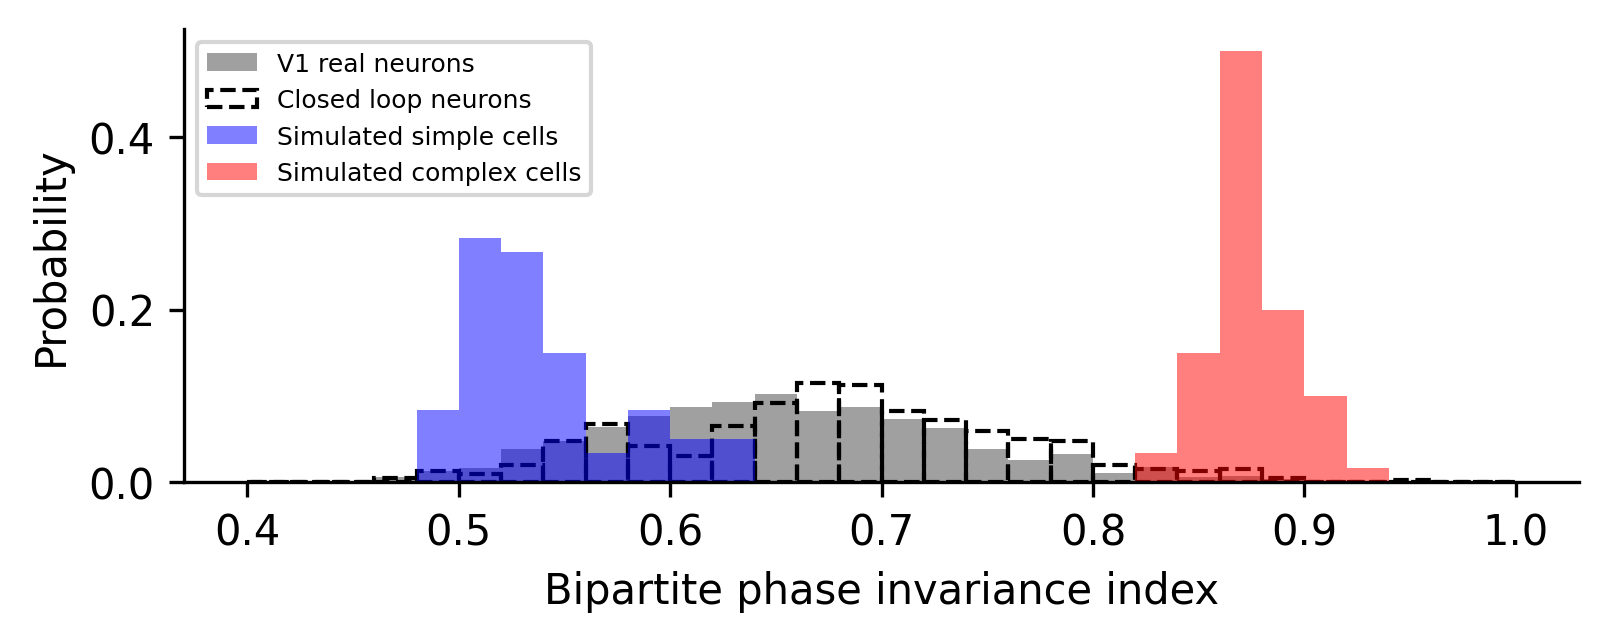

In [58]:
plt.figure(figsize=(6, 2), dpi=300)
min_val, max_val = np.concatenate([real_auc, toy_auc]).min(), np.concatenate([real_auc, toy_auc]).max()
ax = sns.histplot(real_auc, color='gray', stat='probability', binwidth=0.02, binrange=[0.4, 1], label='V1 real neurons', linewidth=0)
ax1 = sns.histplot(loop_auc, color='k', stat='probability', binwidth=0.02, binrange=[0.4, 1], label='Closed loop neurons', fill=False, linestyle='--', linewidth=1)
ax2 = sns.histplot(toy_auc[60:], color='b', stat='probability', binwidth=0.02, binrange=[0.4, 1], label='Simulated simple cells', alpha=0.5, linewidth=0)
ax3 = sns.histplot(toy_auc[:60], color='r', stat='probability', binwidth=0.02, binrange=[0.4, 1], label='Simulated complex cells', alpha=0.5, linewidth=0)
plt.legend(fontsize=6, loc=2)
sns.despine()
plt.xlabel('Bipartite phase invariance index')
plt.savefig('/src/notebooks/Official_figures/[Fig4_g]Bipartite_index_with_toy.pdf', transparent=True)


Text(0.5, 1.0, 'pearson = 1.00')

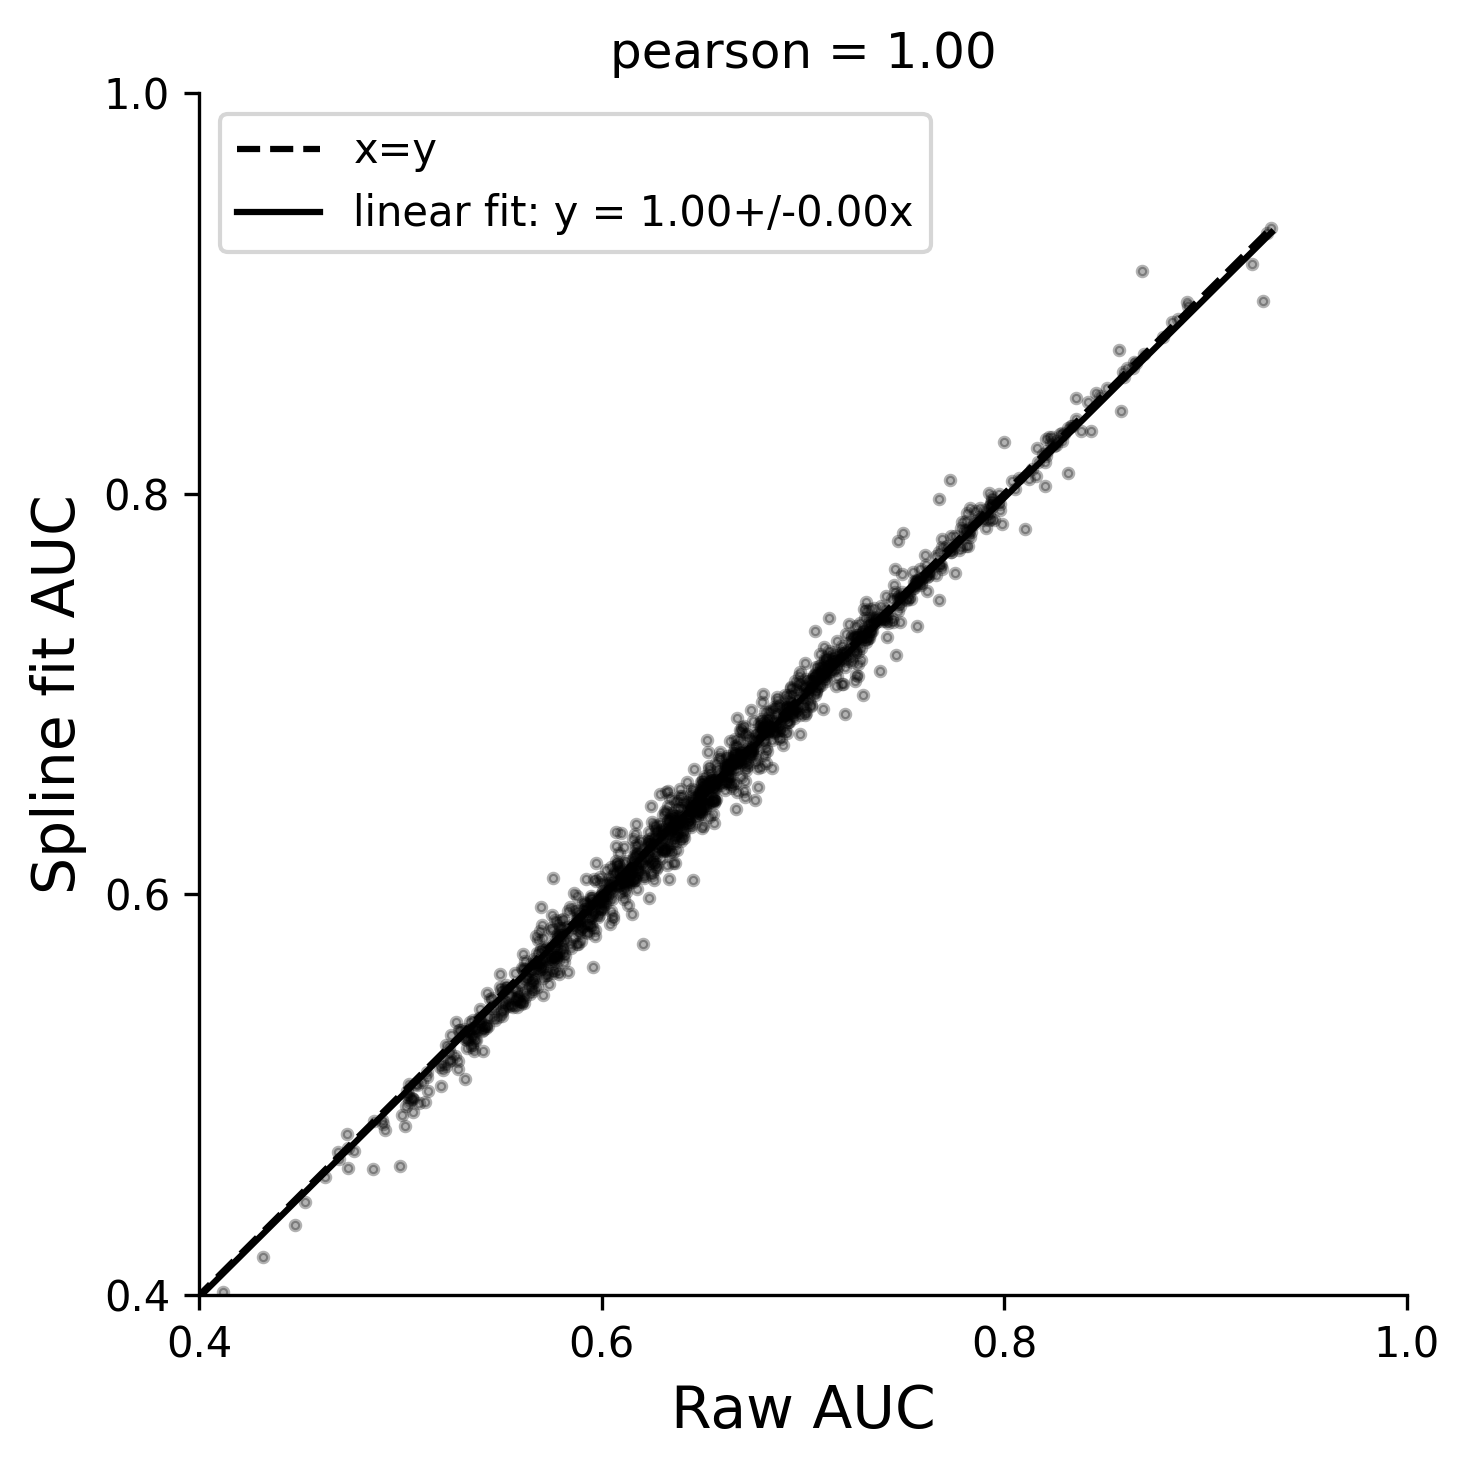

In [64]:
scatterplot_helper(np.array(real_auc_raw), np.array(real_auc), 'Raw AUC', 'Spline fit AUC', get_bound_from_data=True, alpha=0.3)
plt.xlim([0.4, 1])
plt.ylim([0.4, 1])
plt.title('pearson = {:.2f}'.format(scipy.stats.pearsonr(np.array(real_auc_raw), np.array(real_auc))[0]))
# plt.savefig('/src/notebooks/Figures/DEI rebuttal/supplement/[QuantBipartite]Raw_AUC_and_spline_fit_AUC.pdf')

In [61]:
scipy.stats.pearsonr(real_auc, real_auc_raw)

(0.9950165977869095, 0.0)

### AUC robustness across model ensembles

In [65]:
div, vsize = (deis_schema.DEI * deis_schema.Texture & (deis_schema.TextureGoodRun & 'group_id = 342 and seed in (101, 1009)')).fetch('avg_sim', 'p', order_by='seed, group_id, neuron_id')

ps, acts = \
(deis_schema.Texture & 'group_id = 342 and seed in (101, 1009)'
).fetch('p', 'sample_avg_activation_ratio', order_by='seed, group_id, neuron_id, texture_id')
ps = ps.reshape(-1, 10)
acts = acts.reshape(-1, 10)

ps_fscore, ps_target, auc = [], [], []
for p, act in zip(ps, acts):
    fitted_p, fitted_act = deis_schema.spline_fit(p, act, processed=False, mode='spline')
    auc.append(deis_schema.auc_cal(fitted_p, fitted_act))

/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_regression.py:796: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_regression.py:796: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_regression.py:796: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


(0.3832620789336617,
 0.9849556336964268,
 0.38274135756459604,
 0.9958907824468062)

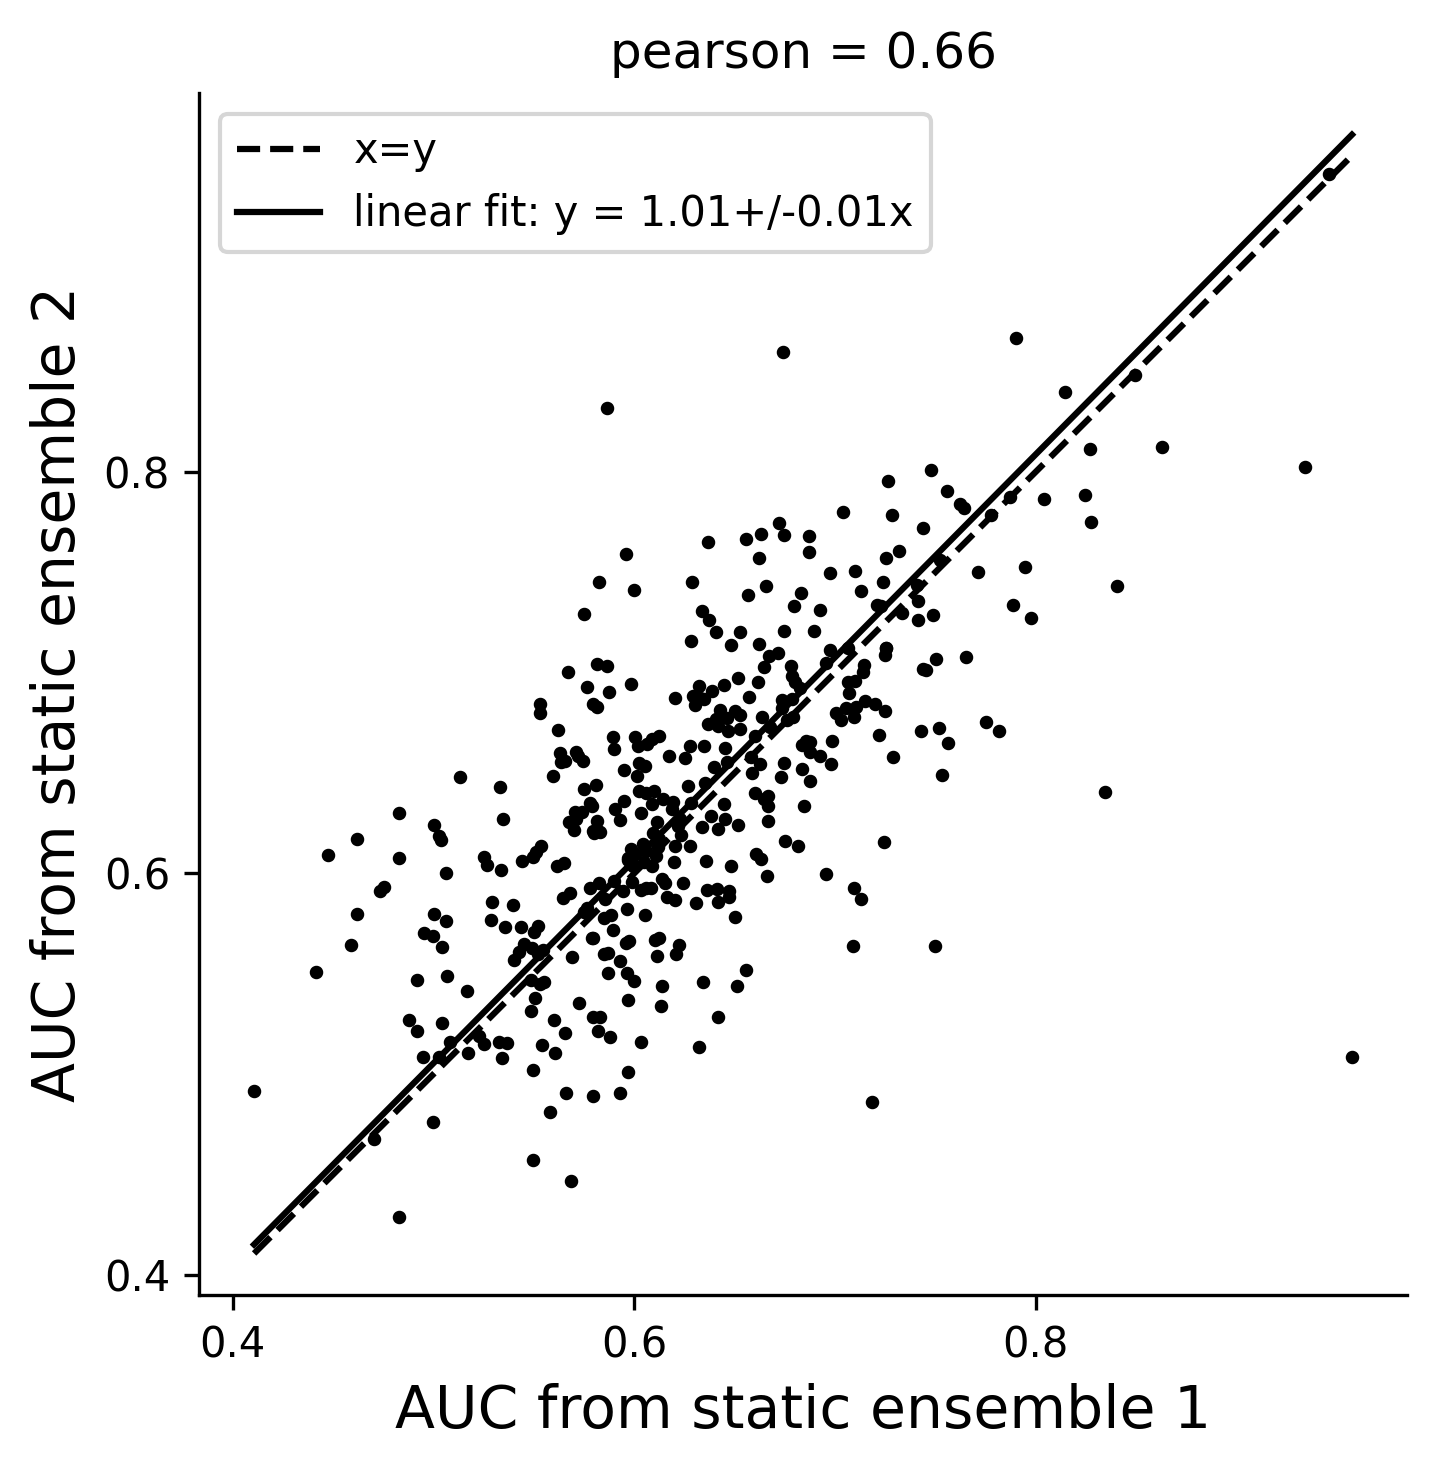

In [66]:
scatterplot_helper(np.array(auc[:400]), np.array(auc[400:]), 'AUC from static ensemble 1', 'AUC from static ensemble 2', get_bound_from_data=True)
plt.xlim([0.4, 1])
plt.ylim([0.4, 1])
plt.title('pearson = {:.2f}'.format(scipy.stats.pearsonr(np.array(auc[:400]), np.array(auc[400:]))[0]))
plt.axis('equal')
# plt.savefig('/src/notebooks/Figures/DEI rebuttal/supplement/[QuantBipartite]Robustness_of_AUC.pdf')

In [69]:
scipy.stats.pearsonr(np.array(auc[:400]), np.array(auc[400:]))

(0.6641102529846499, 3.2100373769737514e-52)